In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [10]:
from tensorflow.keras.utils import to_categorical #분류분석시 원핫인코딩
from tensorflow.keras.models import Sequential #모델생성
from tensorflow.keras.layers import Dense, Input
import numpy as np

# 머신러닝/딥러닝:데이터의 법칙성을 추출
- 다양한 분야에서 응용 : 글씨인식, 문장분류, 질병진단, ...
※ ML/DL의 종류
- 지도학습(독립=입력변수와 종속=타겟=출력변수가 모두 주어졌을 경우)
    회귀분석(타겟변수가 연속형) vs 분류분석(multi, binary)
- 비지도학습(입력변수만)
    군집화
- 강화학습

※지도학습에서의 ML, DL 프로그래밍 방식
1. 데이터 셋 확보(input=입력변수, target=종속변수)
    원본 데이터 및 시뮬레이션을 통해 데이터 생성
2. 전처리
    스케일 조정
    훈련셋(학습셋), 검증셋, 시험셋(테스트셋)
    학습 및 평가 가능한 포맷으로 변환(numpy, DataFrame)
3. 모델 구성
    Sequential 객체 생성뒤 필요한 층을 add()함수로 추가
4. 모델 학습과정 설정
    compile()함수 이용. 손실함수, optimizer, metrics(평가지표)
5. 모델학습시키기(ft. 학습과정 지켜보기)
    fit()함수 이용 - 훈련셋입력=독립변수, 훈련셋타겟=종속변수, 학습횟수, 검증셋
6. 모델 평가
    시험셋(테스트셋)을 인자로 넣은 evaluate()한수 이용, 그래프
7. 모델 사용
    predict() 이용. 입력데이터는 2차원 
8. 모델 저장
    save()함수이용해서 저장. 저장된 모델은 load_model()함수를 이용해서 불러올 수 있음

# 1. 데이터 셋 생성
# 2. 데이터 전처리

In [3]:
#학습데이터 = 훈련데이터
x_train = np.array([1,2,3,4,5,6,7,8,9]*10)
y_train = np.array([2, 4, 6, 8, 10, 12, 14, 16, 18]*10)

#검증데이터
x_val =  np.array([1, 2, 3, 4, 5, 6, 7, 8, 9])
y_val = np.array([2, 4, 6, 8, 10, 12, 14, 16, 18])
# 테스트셋 = 시험데이터
x_test = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9])
y_test = np.array([2, 4, 6, 8, 10, 12, 14, 16, 18])
x_train.shape, x_val.shape, x_test.shape, y_train.shape, y_val.shape, y_test.shape

((90,), (9,), (9,), (90,), (9,), (9,))

In [4]:
# 인코딩 종류
data = np.array(['서울', '경기', '인천', '부산'])
print('원 데이터:', data)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# le.fit(data)
# labeled_data = le.transform(data)
labeled_data = le.fit_transform(data)
print('라벨 인코딩된 데이터 : ', labeled_data)
one_hot_encoded_data = to_categorical(labeled_data)
print('원핫인코딩된 데이터 : ', one_hot_encoded_data)

원 데이터: ['서울' '경기' '인천' '부산']
라벨 인코딩된 데이터 :  [2 0 3 1]
원핫인코딩된 데이터 :  [[0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]]


In [5]:
# 분류분석을 하기 위해, target을 원핫인코딩(라벨링 전환)
data = np.array([1,2,2,4,2])
print(data)
categorical_one_hot = to_categorical(data)
print('to_categorical을 이용한 원핫인코딩:\n', categorical_one_hot)
import pandas as pd
get_dumies_one_hot = pd.get_dummies(data)
display('get_dumies를 이용한 원핫인코딩:', get_dumies_one_hot)
print(type(categorical_one_hot))
print(type(get_dumies_one_hot))

[1 2 2 4 2]
to_categorical을 이용한 원핫인코딩:
 [[0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0.]]


'get_dumies를 이용한 원핫인코딩:'

,1,2,4
0,1,0,0
1,0,1,0
2,0,1,0
3,0,0,1
4,0,1,0


<class 'numpy.ndarray'>
<class 'pandas.core.frame.DataFrame'>


In [6]:
# 분류분석을 위한 target변수 라벨링 전환(=원핫인코딩)
Y_train = to_categorical(y_train, 19)
Y_val = to_categorical(y_val)
Y_test = to_categorical(y_test)
Y_test

array([[0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
        0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
        0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 1.]], dtype=float32)

In [7]:
print('훈련셋 구조:',x_train.shape, Y_train.shape) #독립변수1개, 타겟변수 19개
print('검증셋 구조:',x_val.shape, Y_val.shape)
print('테스트셋 구조:',x_test.shape, Y_test.shape)

훈련셋 구조: (90,) (90, 19)
검증셋 구조: (9,) (9, 19)
테스트셋 구조: (9,) (9, 19)


# 3. 모델 구성하기

In [11]:
model = Sequential()
model.add(Input(shape=(1,))) #입력층
model.add(Dense(units=38, activation='sigmoid')) #unit 출력수, 활성화함수:elu, tanh, sigmoid
model.add(Dense(units=64, activation='elu'))
model.add(Dense(units=32, activation='elu'))
model.add(Dense(units=19, activation='softmax'))
# softmax : 모든 출력결과의 합이 1. 분류분석 마지막 layer(출력층)dptj activation 으로 
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 38)                76        
                                                                 
 dense_1 (Dense)             (None, 64)                2496      
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 19)                627       
                                                                 
Total params: 5,279
Trainable params: 5,279
Non-trainable params: 0
_________________________________________________________________


# 4. 모델 학습과정 설정

In [12]:
model.compile(loss="categorical_crossentropy", #분류분석에서의 손실함수(원핫인코딩有)
             optimizer='sgd',
             metrics=['accuracy']) #평가지표 : accuracy

# 5. 모델 학습시키기

In [15]:
hist = model.fit(x_train, Y_train,
                epochs=300, 
                batch_size=10,
                verbose=2, #학습결과 출력 옵션 0:출력없음 1:기본값, 2:에포크별로그상세출력
                validation_data=(x_val, Y_val)
                )

Epoch 1/300
9/9 - 1s - loss: 3.1539 - accuracy: 0.1111 - val_loss: 3.0393 - val_accuracy: 0.1111 - 514ms/epoch - 57ms/step
Epoch 2/300
9/9 - 0s - loss: 2.9847 - accuracy: 0.1111 - val_loss: 2.8998 - val_accuracy: 0.1111 - 44ms/epoch - 5ms/step
Epoch 3/300
9/9 - 0s - loss: 2.8655 - accuracy: 0.1111 - val_loss: 2.7944 - val_accuracy: 0.1111 - 47ms/epoch - 5ms/step
Epoch 4/300
9/9 - 0s - loss: 2.7684 - accuracy: 0.1222 - val_loss: 2.7084 - val_accuracy: 0.2222 - 41ms/epoch - 5ms/step
Epoch 5/300
9/9 - 0s - loss: 2.6851 - accuracy: 0.1222 - val_loss: 2.6325 - val_accuracy: 0.1111 - 41ms/epoch - 5ms/step
Epoch 6/300
9/9 - 0s - loss: 2.6157 - accuracy: 0.1111 - val_loss: 2.5659 - val_accuracy: 0.1111 - 44ms/epoch - 5ms/step
Epoch 7/300
9/9 - 0s - loss: 2.5532 - accuracy: 0.1111 - val_loss: 2.5068 - val_accuracy: 0.2222 - 43ms/epoch - 5ms/step
Epoch 8/300
9/9 - 0s - loss: 2.4951 - accuracy: 0.1778 - val_loss: 2.4532 - val_accuracy: 0.2222 - 41ms/epoch - 5ms/step
Epoch 9/300
9/9 - 0s - loss: 2

Epoch 69/300
9/9 - 0s - loss: 1.4560 - accuracy: 0.5778 - val_loss: 1.4289 - val_accuracy: 0.5556 - 43ms/epoch - 5ms/step
Epoch 70/300
9/9 - 0s - loss: 1.4480 - accuracy: 0.5556 - val_loss: 1.4178 - val_accuracy: 0.5556 - 44ms/epoch - 5ms/step
Epoch 71/300
9/9 - 0s - loss: 1.4391 - accuracy: 0.4667 - val_loss: 1.4081 - val_accuracy: 0.5556 - 39ms/epoch - 4ms/step
Epoch 72/300
9/9 - 0s - loss: 1.4346 - accuracy: 0.5667 - val_loss: 1.3986 - val_accuracy: 0.6667 - 40ms/epoch - 4ms/step
Epoch 73/300
9/9 - 0s - loss: 1.4148 - accuracy: 0.6778 - val_loss: 1.3908 - val_accuracy: 0.5556 - 42ms/epoch - 5ms/step
Epoch 74/300
9/9 - 0s - loss: 1.4098 - accuracy: 0.6000 - val_loss: 1.3804 - val_accuracy: 0.5556 - 39ms/epoch - 4ms/step
Epoch 75/300
9/9 - 0s - loss: 1.3958 - accuracy: 0.5667 - val_loss: 1.3716 - val_accuracy: 0.6667 - 41ms/epoch - 5ms/step
Epoch 76/300
9/9 - 0s - loss: 1.3894 - accuracy: 0.5556 - val_loss: 1.3628 - val_accuracy: 0.7778 - 43ms/epoch - 5ms/step
Epoch 77/300
9/9 - 0s - 

Epoch 136/300
9/9 - 0s - loss: 0.9962 - accuracy: 0.8222 - val_loss: 0.9675 - val_accuracy: 0.8889 - 50ms/epoch - 6ms/step
Epoch 137/300
9/9 - 0s - loss: 0.9878 - accuracy: 0.8000 - val_loss: 0.9668 - val_accuracy: 0.8889 - 42ms/epoch - 5ms/step
Epoch 138/300
9/9 - 0s - loss: 0.9818 - accuracy: 0.8444 - val_loss: 0.9567 - val_accuracy: 1.0000 - 42ms/epoch - 5ms/step
Epoch 139/300
9/9 - 0s - loss: 0.9825 - accuracy: 0.8333 - val_loss: 0.9491 - val_accuracy: 0.7778 - 40ms/epoch - 4ms/step
Epoch 140/300
9/9 - 0s - loss: 0.9924 - accuracy: 0.7778 - val_loss: 0.9450 - val_accuracy: 0.8889 - 43ms/epoch - 5ms/step
Epoch 141/300
9/9 - 0s - loss: 0.9656 - accuracy: 0.8444 - val_loss: 0.9398 - val_accuracy: 0.8889 - 42ms/epoch - 5ms/step
Epoch 142/300
9/9 - 0s - loss: 0.9706 - accuracy: 0.8000 - val_loss: 0.9493 - val_accuracy: 0.8889 - 41ms/epoch - 5ms/step
Epoch 143/300
9/9 - 0s - loss: 0.9613 - accuracy: 0.7889 - val_loss: 0.9300 - val_accuracy: 0.8889 - 43ms/epoch - 5ms/step
Epoch 144/300
9/

Epoch 203/300
9/9 - 0s - loss: 0.7330 - accuracy: 0.9000 - val_loss: 0.6936 - val_accuracy: 1.0000 - 43ms/epoch - 5ms/step
Epoch 204/300
9/9 - 0s - loss: 0.7208 - accuracy: 0.9000 - val_loss: 0.6915 - val_accuracy: 1.0000 - 43ms/epoch - 5ms/step
Epoch 205/300
9/9 - 0s - loss: 0.7261 - accuracy: 0.8444 - val_loss: 0.6785 - val_accuracy: 0.8889 - 41ms/epoch - 5ms/step
Epoch 206/300
9/9 - 0s - loss: 0.7241 - accuracy: 0.8333 - val_loss: 0.6947 - val_accuracy: 0.7778 - 39ms/epoch - 4ms/step
Epoch 207/300
9/9 - 0s - loss: 0.7061 - accuracy: 0.8333 - val_loss: 0.6818 - val_accuracy: 0.8889 - 43ms/epoch - 5ms/step
Epoch 208/300
9/9 - 0s - loss: 0.7007 - accuracy: 0.8667 - val_loss: 0.6682 - val_accuracy: 1.0000 - 39ms/epoch - 4ms/step
Epoch 209/300
9/9 - 0s - loss: 0.6839 - accuracy: 0.9222 - val_loss: 0.6672 - val_accuracy: 0.8889 - 53ms/epoch - 6ms/step
Epoch 210/300
9/9 - 0s - loss: 0.6870 - accuracy: 0.9333 - val_loss: 0.6607 - val_accuracy: 1.0000 - 40ms/epoch - 4ms/step
Epoch 211/300
9/

Epoch 270/300
9/9 - 0s - loss: 0.5256 - accuracy: 0.9778 - val_loss: 0.5033 - val_accuracy: 0.8889 - 40ms/epoch - 4ms/step
Epoch 271/300
9/9 - 0s - loss: 0.5361 - accuracy: 0.8778 - val_loss: 0.5606 - val_accuracy: 0.7778 - 43ms/epoch - 5ms/step
Epoch 272/300
9/9 - 0s - loss: 0.4998 - accuracy: 0.9111 - val_loss: 0.4846 - val_accuracy: 0.8889 - 44ms/epoch - 5ms/step
Epoch 273/300
9/9 - 0s - loss: 0.4982 - accuracy: 0.9556 - val_loss: 0.5780 - val_accuracy: 0.7778 - 41ms/epoch - 5ms/step
Epoch 274/300
9/9 - 0s - loss: 0.5359 - accuracy: 0.9000 - val_loss: 0.5025 - val_accuracy: 0.8889 - 43ms/epoch - 5ms/step
Epoch 275/300
9/9 - 0s - loss: 0.5082 - accuracy: 0.9444 - val_loss: 0.4747 - val_accuracy: 1.0000 - 42ms/epoch - 5ms/step
Epoch 276/300
9/9 - 0s - loss: 0.5023 - accuracy: 0.9333 - val_loss: 0.4661 - val_accuracy: 1.0000 - 40ms/epoch - 4ms/step
Epoch 277/300
9/9 - 0s - loss: 0.4925 - accuracy: 1.0000 - val_loss: 0.4619 - val_accuracy: 1.0000 - 41ms/epoch - 5ms/step
Epoch 278/300
9/

# 6. 모델 평가하기(모델학습과정 살펴보고, evalate)

In [17]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

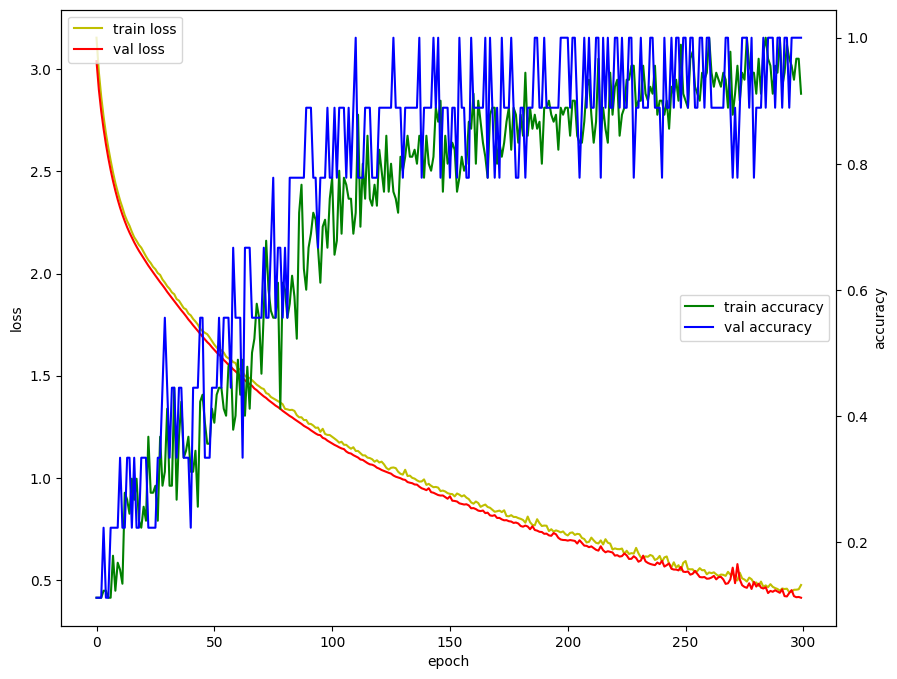

In [23]:
# 모델 학습과정 시각화
import matplotlib.pyplot as plt
fig, loss_ax = plt.subplots(figsize=(10,8))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')

acc_ax = loss_ax.twinx() #loss_ax와 x축을 공유하는 acc_ax생성
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='upper left')
acc_ax.legend(loc='center right')
plt.show()

In [24]:
# 모델 평가
score = model.evaluate(x_test, Y_test, batch_size=1)

9/9 [==============================] - 0s 2ms/step - loss: 0.4134 - accuracy: 1.0000


In [26]:
score #loss, accuracy

[0.4133812189102173, 1.0]

In [27]:
print('평가된 loss:', score[0])
print('평가된 accuracy:', score[1]*100, '%')

평가된 loss: 0.4133812189102173
평가된 accuracy: 100.0 %


# 7. 모델 사용하기

In [33]:
H = model.predict(np.array([[2]]))
H

1/1 [==============================] - 0s 34ms/step


array([[6.2213994e-14, 2.0872815e-10, 7.4654110e-02, 5.3335934e-12,
        8.3873028e-01, 5.3261273e-10, 8.4124200e-02, 2.5791723e-08,
        2.4894769e-03, 9.0721972e-15, 1.8817443e-06, 7.0968031e-13,
        1.7319964e-09, 2.6151251e-12, 8.3829330e-13, 6.2732127e-13,
        1.3827624e-17, 1.8997011e-14, 8.8767126e-25]], dtype=float32)

In [34]:
# 분류분석의 예측은 predict()후 argmax()
model.predict(np.array([[2]])).argmax()

1/1 [==============================] - 0s 21ms/step


4

In [35]:
# 4를 몇 %확률로 예측했는지
H[0, H.argmax()]*100

83.87302756309509

# 7. 모델 저장하기

In [13]:
#model.save('model/02_deep.h5')
from tensorflow.keras.models import save_model
save_model(model, 'model/02_deep.h5')

## 저장된 모델 사용하기

In [2]:
from tensorflow.keras.models import load_model
model2 = load_model('model/02_deep.h5')

In [4]:
model2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 38)                76        
                                                                 
 dense_5 (Dense)             (None, 64)                2496      
                                                                 
 dense_6 (Dense)             (None, 32)                2080      
                                                                 
 dense_7 (Dense)             (None, 19)                627       
                                                                 
Total params: 5,279
Trainable params: 5,279
Non-trainable params: 0
_________________________________________________________________


In [16]:
import numpy as np
data = np.array([[2],
                [3]])
predictions = model.predict(data)
predictions.argmax(axis=-1)

1/1 [==============================] - 0s 32ms/step


array([1, 1], dtype=int64)

In [17]:
def predict_classes(model, data):
    predictions = model.predict(data)
    return predictions.argmax(axis=-1)

In [19]:
input_data = int(input('어떤 데이터를 예측할까요?'))
data = np.array([[input_data]])
print(data)

어떤 데이터를 예측할까요?2
[[2]]


In [20]:
import tensorflow as tf
@tf.function(reduce_retracing=True)
def predict_classes(model, data):
    prediction = model(data, training=False)
    return tf.argmax(predictions, axis=-1)

In [24]:
input_data = int(input('어떤 데이터를 예측할까요?'))
data = np.array([[input_data]])
print('예측된 분류는:',predict_classes(model2, data))

어떤 데이터를 예측할까요?2
예측된 분류는: tf.Tensor([1 1], shape=(2,), dtype=int64)
